# Punto 4 (libre) – ¿Llegará tarde este pedido?
**Red neuronal construida con NumPy**

**Problema:** una empresa de distribución quiere predecir, antes de despachar, si un pedido va a llegar **tarde** (1) o a **tiempo** (0).

| Elementos | En este ejercicio |
|---|---|
| X (features) | distancia (km), peso (kg), lluvia (0/1), hora pico (0/1) |
| Y (rótulo) | 1 = llega tarde, 0 = a tiempo (clasificación binaria) |
| Propagación | Z⁽ⁱ⁾ = B⁽ⁱ⁾ + W⁽ⁱ⁾ᵀ A⁽ⁱ⁻¹⁾, A⁽ⁱ⁾ = σ(Z⁽ⁱ⁾) |
| Pérdida | E = ½ e², con e = Yr − Y |
| Backpropagation | δᵏ = diag(σ′(Zᵏ)) W⁽ᵏ⁺¹⁾ᵀ δᵏ⁺¹ |
| Actualización | descenso del gradiente con tasa de aprendizaje η |

**Idea central:** primero una sola neurona, luego una red con capas ocultas, y se compara. Así se ve por qué las capas ocultas y la función de activación le dan "complejidad" a la red.

## 1. Generación de datos ("historial de entregas")

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
np.random.seed(7)

m = 3000   # número de ejemplos de entrenamiento + prueba
distancia = np.random.uniform(1, 100, m)     # km
peso      = np.random.uniform(10, 1000, m)   # kg
lluvia    = np.random.binomial(1, 0.3, m)    # 1 = llueve
hora_pico = np.random.binomial(1, 0.4, m)    # 1 = sale en hora pico

# Regla "oculta" del mundo real (la red NO la conoce, debe aprenderla de los datos):
# la lluvia empeora más los viajes largos, y la hora pico solo afecta viajes de más de 40 km.
riesgo = (distancia/100)*(1 + 1.2*lluvia) + 0.6*hora_pico*(distancia > 40) \
         + 0.4*(peso/1000) + np.random.normal(0, 0.08, m)
tarde = (riesgo > 1.0).astype(int)

df = pd.DataFrame({"distancia_km": distancia, "peso_kg": peso,
                   "lluvia": lluvia, "hora_pico": hora_pico, "tarde": tarde})
display(df.head(8))
print(f"Porcentaje de pedidos tarde: {tarde.mean():.1%}")

,distancia_km,peso_kg,lluvia,hora_pico,tarde
0,8.554521,693.120455,0,0,0
1,78.211960,676.233355,0,0,1
2,44.402514,898.277194,0,0,0
3,72.623053,348.044744,0,0,0
4,97.820962,551.705395,1,0,1
5,54.311091,221.461330,1,1,1
6,50.610926,339.478243,1,0,1
7,8.133062,823.631842,0,0,0


Porcentaje de pedidos tarde: 44.3%


## 2. Estudiar las características (features) y el rótulo

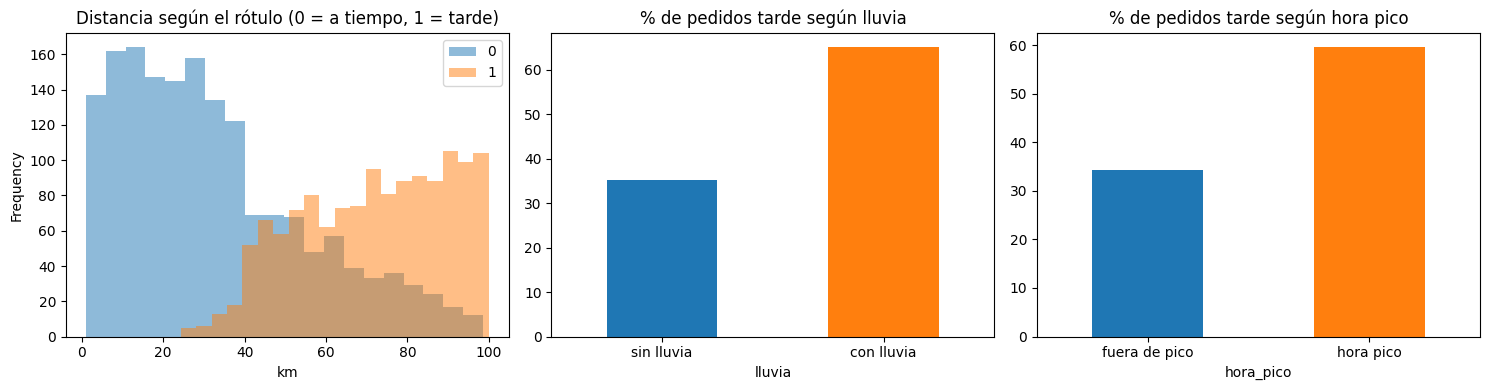

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

df.groupby("tarde")["distancia_km"].plot(kind="hist", alpha=0.5, bins=20, ax=ax[0], legend=True)
ax[0].set_title("Distancia según el rótulo (0 = a tiempo, 1 = tarde)"); ax[0].set_xlabel("km")

(df.groupby("lluvia")["tarde"].mean()*100).plot(kind="bar", ax=ax[1], color=["tab:blue","tab:orange"])
ax[1].set_title("% de pedidos tarde según lluvia"); ax[1].set_xticklabels(["sin lluvia","con lluvia"], rotation=0)

(df.groupby("hora_pico")["tarde"].mean()*100).plot(kind="bar", ax=ax[2], color=["tab:blue","tab:orange"])
ax[2].set_title("% de pedidos tarde según hora pico"); ax[2].set_xticklabels(["fuera de pico","hora pico"], rotation=0)
plt.tight_layout(); plt.show()

## 3. Preparar X y Y
- Normalizamos cada feature a [0, 1] (los pesos funcionan mejor si las entradas tienen escalas parecidas: 1–100 km frente a 0/1).
- Dividimos: **80 % entrenamiento** y **20 % prueba**.
- Cada **columna** de X es un ejemplo, como en el documento (vector X de n features).

In [3]:
features = ["distancia_km", "peso_kg", "lluvia", "hora_pico"]
F = df[features].values
f_min, f_max = F.min(axis=0), F.max(axis=0)
Xn = (F - f_min) / (f_max - f_min)

idx = np.random.permutation(m)
n_train = int(0.8 * m)
tr, te = idx[:n_train], idx[n_train:]

X_train, Y_train = Xn[tr].T, df["tarde"].values[tr].reshape(1, -1)
X_test,  Y_test  = Xn[te].T, df["tarde"].values[te].reshape(1, -1)
print("X_train:", X_train.shape, "(features x ejemplos) | Y_train:", Y_train.shape)

X_train: (4, 2400) (features x ejemplos) | Y_train: (1, 2400)


## 4. Red neuronal (ecuaciones)

In [4]:
def sig(z):                       # función de activación sigmoide
    return 1 / (1 + np.exp(-z))

def inicializar(topologia):      # topologia = [n_entradas, neuronas capa 1, ..., neuronas de salida]
    W = [np.random.randn(topologia[i+1], topologia[i]) * 0.5 for i in range(len(topologia)-1)]
    b = [np.zeros((topologia[i+1], 1)) for i in range(len(topologia)-1)]
    return W, b

def propaga(X, W, b):            # Z(i) = W(i) A(i-1) + B(i);  A(i) = sig(Z(i))
    A = [X]
    for Wi, bi in zip(W, b):
        A.append(sig(Wi @ A[-1] + bi))
    return A                     # A[-1] es la salida Hw(X)

def backpropagation(A, Y, W):
    m = Y.shape[1]
    L = len(W)
    e = Y - A[-1]                              # error: e = Yr - Y
    delta = e * A[-1] * (1 - A[-1])            # delta de la última capa = diag(sig'(Z)) e   (sig' = sig(1-sig))
    dW, db = [None]*L, [None]*L
    for k in reversed(range(L)):
        dW[k] = delta @ A[k].T / m             # componente de corrección de W
        db[k] = delta.sum(axis=1, keepdims=True) / m   # componente de corrección del sesgo B
        if k > 0:                              # se pasa el error hacia atrás: delta(k) = diag(sig') W(k+1)^T delta(k+1)
            delta = (W[k].T @ delta) * A[k] * (1 - A[k])
    return dW, db

def entrenar(topologia, eta, epocas):
    W, b = inicializar(topologia)
    historia = {"perdida": [], "acc_train": [], "acc_test": []}
    for i in range(epocas):
        A = propaga(X_train, W, b)
        dW, db = backpropagation(A, Y_train, W)
        for k in range(len(W)):                # como e = Yr - Y, los pesos se SUMAN
            W[k] += eta * dW[k]
            b[k] += eta * db[k]
        if i % 50 == 0:
            e = Y_train - A[-1]
            historia["perdida"].append(0.5 * np.mean(e**2))
            historia["acc_train"].append(exactitud(X_train, Y_train, W, b))
            historia["acc_test"].append(exactitud(X_test, Y_test, W, b))
    return W, b, historia

def exactitud(X, Y, W, b):
    return ((propaga(X, W, b)[-1] > 0.5) == Y).mean()

## 5. Entrenamiento: una neurona vs. una red con capas ocultas
- **Modelo A:** Una sola neurona (topología `[4, 1]`).
- **Modelo B:** Red con 2 capas ocultas (topología `[4, 8, 4, 1]`).

In [5]:
W_a, b_a, h_a = entrenar([4, 1],       eta=5, epocas=5000)
W_b, b_b, h_b = entrenar([4, 8, 4, 1], eta=5, epocas=5000)

print(f"Modelo A (1 neurona)      -> exactitud entrenamiento: {exactitud(X_train,Y_train,W_a,b_a):.1%} | prueba: {exactitud(X_test,Y_test,W_a,b_a):.1%}")
print(f"Modelo B (capas ocultas)  -> exactitud entrenamiento: {exactitud(X_train,Y_train,W_b,b_b):.1%} | prueba: {exactitud(X_test,Y_test,W_b,b_b):.1%}")

Modelo A (1 neurona)      -> exactitud entrenamiento: 90.8% | prueba: 91.5%
Modelo B (capas ocultas)  -> exactitud entrenamiento: 95.9% | prueba: 96.7%


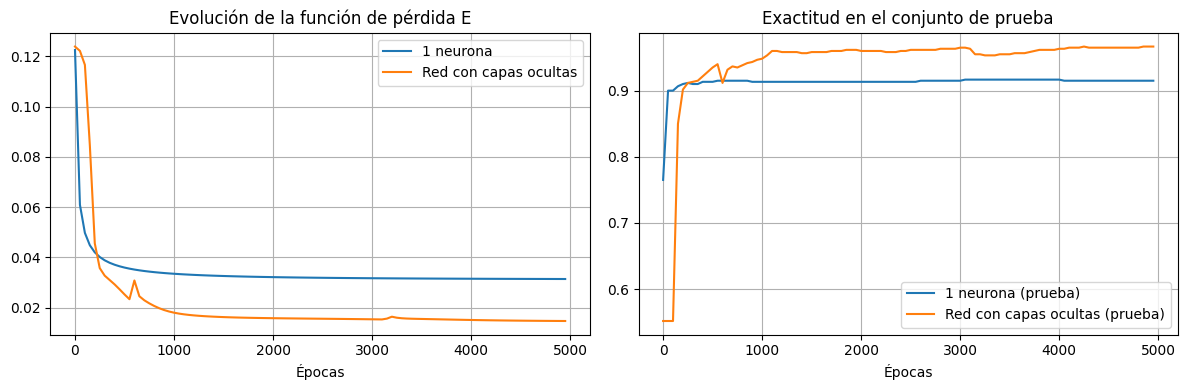

In [6]:
epocas_eje = np.arange(len(h_b["perdida"])) * 50
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epocas_eje, h_a["perdida"], label="1 neurona")
ax[0].plot(epocas_eje, h_b["perdida"], label="Red con capas ocultas")
ax[0].set_title("Evolución de la función de pérdida E"); ax[0].set_xlabel("Épocas"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(epocas_eje, h_a["acc_test"], label="1 neurona (prueba)")
ax[1].plot(epocas_eje, h_b["acc_test"], label="Red con capas ocultas (prueba)")
ax[1].set_title("Exactitud en el conjunto de prueba"); ax[1].set_xlabel("Épocas"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

## 6. Evaluar el mejor modelo (matriz de confusión)

In [7]:
pred = (propaga(X_test, W_b, b_b)[-1] > 0.5).astype(int).flatten()
real = Y_test.flatten()

tp = int(((pred==1)&(real==1)).sum()); tn = int(((pred==0)&(real==0)).sum())
fp = int(((pred==1)&(real==0)).sum()); fn = int(((pred==0)&(real==1)).sum())

print(pd.DataFrame([[tn, fp], [fn, tp]],
                   index=["Real: a tiempo", "Real: tarde"],
                   columns=["Predicho: a tiempo", "Predicho: tarde"]))
print(f"\nExactitud: {(tp+tn)/len(real):.1%}")
print(f"Precisión (de los que dijo 'tarde', cuántos lo eran): {tp/(tp+fp):.1%}")
print(f"Recall (de los que realmente fueron tarde, cuántos detectó): {tp/(tp+fn):.1%}")

                Predicho: a tiempo  Predicho: tarde
Real: a tiempo                 321               10
Real: tarde                     10              259

Exactitud: 96.7%
Precisión (de los que dijo 'tarde', cuántos lo eran): 96.3%
Recall (de los que realmente fueron tarde, cuántos detectó): 96.3%


## 7. Usar la red: predecir un pedido nuevo
Cambia los valores y ejecuta la celda. Prueba el mismo pedido con y sin lluvia para ver cómo cambia la predicción.

In [8]:
def predecir_pedido(distancia_km, peso_kg, lluvia, hora_pico):
    x = (np.array([distancia_km, peso_kg, lluvia, hora_pico], dtype=float) - f_min) / (f_max - f_min)
    p = propaga(x.reshape(-1, 1), W_b, b_b)[-1].item()
    veredicto = "LLEGARÁ TARDE" if p > 0.5 else "llegará a tiempo"
    print(f"{distancia_km} km, {peso_kg} kg, lluvia={lluvia}, hora pico={hora_pico}  ->  prob. de retraso = {p:.0%}  ->  {veredicto}")

predecir_pedido(80, 500, 0, 0)
predecir_pedido(80, 500, 1, 0)   # mismo pedido, ahora con lluvia
predecir_pedido(60, 300, 0, 1)   # viaje medio en hora pico
predecir_pedido(10, 800, 1, 1)   # viaje corto

80 km, 500 kg, lluvia=0, hora pico=0  ->  prob. de retraso = 57%  ->  LLEGARÁ TARDE
80 km, 500 kg, lluvia=1, hora pico=0  ->  prob. de retraso = 100%  ->  LLEGARÁ TARDE
60 km, 300 kg, lluvia=0, hora pico=1  ->  prob. de retraso = 100%  ->  LLEGARÁ TARDE
10 km, 800 kg, lluvia=1, hora pico=1  ->  prob. de retraso = 1%  ->  llegará a tiempo
